In [27]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

In [47]:
def load_and_prepare(filename):
    """
    Load a stock CSV, clean it, compute log-returns and
    60-day realized volatility (annualized).
    Returns a DataFrame with columns: Date, LogRet, RV
    """

    # ---- 1.1 Read the CSV ----
    df = pd.read_csv(filename)
    print(f"Loaded {filename}, shape = {df.shape}")

    # Some providers use 'Close*' instead of 'Close'
    if "Close*" in df.columns and "Close" not in df.columns:
        df = df.rename(columns={"Close*": "Close"})

    # ---- 1.2 Convert Date to datetime ----
    # If this format fails, remove "format=..." and let pandas guess.
    df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")

    # ---- 1.3 Clean Close prices (remove commas, convert to float) ----
    df["Close"] = (
        df["Close"]
        .astype(str)                # make sure it's string
        .str.replace(",", "")       # remove thousands commas: "5,881.63" -> "5881.63"
    )
    df["Close"] = pd.to_numeric(df["Close"], errors="coerce")

    # ---- 1.4 Sort by Date ----
    df = df.sort_values("Date")

    # ---- 1.5 Compute daily log-returns ----
    df["LogRet"] = np.log(df["Close"] / df["Close"].shift(1))

    # ---- 1.6 Compute 60-day rolling realized volatility (annualized) ----
    df["RV"] = df["LogRet"].rolling(window=60).std() * np.sqrt(252)

    # ---- 1.7 Keep only what we need ----
    return df[["Date", "LogRet", "RV"]]



In [48]:
# 2. Load and prepare ALL FOUR FILES
# ============================================================
aapl = load_and_prepare('/Users/ambervo/Library/CloudStorage/OneDrive-Personal/Documents/GMBA 3/FinTech/Group Project/data/Apple Stock Price History.csv')
nvda = load_and_prepare('/Users/ambervo/Library/CloudStorage/OneDrive-Personal/Documents/GMBA 3/FinTech/Group Project/data/NVIDIA Stock Price History.csv')
tsla = load_and_prepare('/Users/ambervo/Library/CloudStorage/OneDrive-Personal/Documents/GMBA 3/FinTech/Group Project/data/Tesla Stock Price History.csv')
spx  = load_and_prepare('/Users/ambervo/Library/CloudStorage/OneDrive-Personal/Documents/GMBA 3/FinTech/Group Project/data/S&P 500 - Historical Data.csv')

# Rename columns so we know which series is which after merging
aapl = aapl.rename(columns={"LogRet": "RET_AAPL", "RV": "RV_AAPL"})
nvda = nvda.rename(columns={"LogRet": "RET_NVDA", "RV": "RV_NVDA"})
tsla = tsla.rename(columns={"LogRet": "RET_TSLA", "RV": "RV_TSLA"})
spx  = spx.rename(columns={"LogRet": "RET_SPX",  "RV": "RV_SPX"})

Loaded /Users/ambervo/Library/CloudStorage/OneDrive-Personal/Documents/GMBA 3/FinTech/Group Project/data/Apple Stock Price History.csv, shape = (3774, 7)
Loaded /Users/ambervo/Library/CloudStorage/OneDrive-Personal/Documents/GMBA 3/FinTech/Group Project/data/NVIDIA Stock Price History.csv, shape = (3774, 7)
Loaded /Users/ambervo/Library/CloudStorage/OneDrive-Personal/Documents/GMBA 3/FinTech/Group Project/data/Tesla Stock Price History.csv, shape = (3651, 7)
Loaded /Users/ambervo/Library/CloudStorage/OneDrive-Personal/Documents/GMBA 3/FinTech/Group Project/data/S&P 500 - Historical Data.csv, shape = (3774, 7)


In [49]:
# ============================================================
# 3. Merge all four on Date into one DataFrame
# ============================================================
data = (
    spx.merge(aapl, on="Date")
       .merge(nvda, on="Date")
       .merge(tsla, on="Date")
)

# Drop rows with NaN from rolling calculations
data = data.dropna().reset_index(drop=True)

print("\nMerged data shape:", data.shape)
print(data.head())


Merged data shape: (3591, 9)
        Date   RET_SPX    RV_SPX  RET_AAPL   RV_AAPL  RET_NVDA   RV_NVDA  \
0 2010-09-24  0.021026  0.185841  0.011561  0.223556  0.066691  0.592495   
1 2010-09-27 -0.005675  0.186193 -0.003839  0.221820 -0.032790  0.596982   
2 2010-09-28  0.004804  0.185805 -0.015504  0.224300  0.000000  0.596982   
3 2010-09-29 -0.002617  0.185893  0.001951  0.224124  0.000000  0.590685   
4 2010-09-30 -0.003062  0.175986 -0.012752  0.212283 -0.033902  0.574910   

   RET_TSLA   RV_TSLA  
0  0.030305  0.750741  
1  0.022141  0.732411  
2  0.042864  0.685378  
3  0.027588  0.574043  
4 -0.077778  0.596875  


In [50]:
# ============================================================
# 4. Benchmark OLS: RV_SPX ~ RV_AAPL + RV_NVDA + RV_TSLA
# ============================================================
y = data["RV_SPX"]                               # dependent variable
X = data[["RV_AAPL", "RV_NVDA", "RV_TSLA"]]     # explanatory vars
X = sm.add_constant(X)                          # add intercept

ols_model = sm.OLS(y, X).fit()

print("\n================ OLS BENCHMARK RESULTS ================")
print(ols_model.summary())


================ OLS BENCHMARK RESULTS ================
                            OLS Regression Results                            
Dep. Variable:                 RV_SPX   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.750
Method:                 Least Squares   F-statistic:                     3591.
Date:                Sat, 15 Nov 2025   Prob (F-statistic):               0.00
Time:                        21:51:45   Log-Likelihood:                 6336.3
No. Observations:                3591   AIC:                        -1.266e+04
Df Residuals:                    3587   BIC:                        -1.264e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

In [51]:
# ============================================================
# 5. (Optional) In-sample error metrics
# ============================================================
data["RV_SPX_hat"] = ols_model.fittedvalues
rmse = np.sqrt(np.mean((data["RV_SPX"] - data["RV_SPX_hat"])**2))
mae  = np.mean(np.abs(data["RV_SPX"] - data["RV_SPX_hat"]))

print("\nIn-sample RMSE:", rmse)
print("In-sample MAE :", mae)


In-sample RMSE: 0.04144268095020305
In-sample MAE : 0.030568329711384377


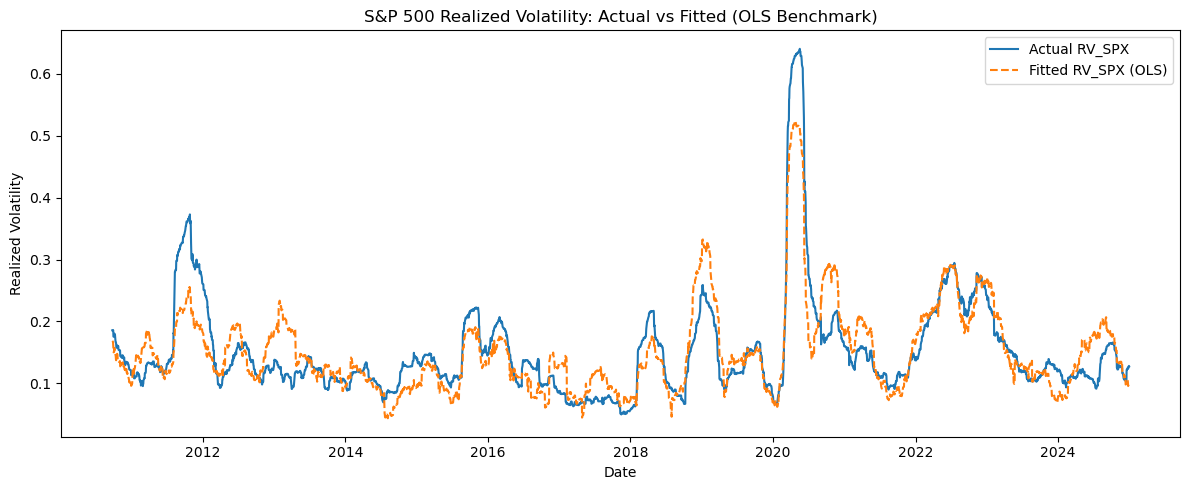

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(data["Date"], data["RV_SPX"], label="Actual RV_SPX")
plt.plot(data["Date"], data["RV_SPX_hat"], label="Fitted RV_SPX (OLS)", linestyle="--")
plt.xlabel("Date")
plt.ylabel("Realized Volatility")
plt.title("S&P 500 Realized Volatility: Actual vs Fitted (OLS Benchmark)")
plt.legend()
plt.tight_layout()
plt.show()
